# Homework 7 - Devin Lim, Duong Le, Lakshit Gupta, Ponnu Soman

Tasks are tracked here: https://github.com/DATA5310/covid_effects/milestone/4

In [1]:
import git
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings("ignore")

## Load the Data

In [3]:
repo = git.Repo(".", search_parent_directories=True).working_tree_dir
cdi_processed_path = f"{repo}/datasets/processed/cdi.csv"

In [6]:
cdi_dtype = {
    "YearStart": "category",
    "YearEnd": "category",
    "LocationAbbr": "category",
    "Topic": "category",
    "Question": "category",
    "DataValueUnit": "category",
    "DataValueType": "category",
    "StratificationCategory1": "category",
    "Stratification1": "category",
}

cdi_df = pd.read_csv(cdi_processed_path, dtype=cdi_dtype)

In [8]:
cdi_df.head()

,YearStart,YearEnd,LocationAbbr,Topic,Question,DataValueUnit,DataValueType,DataValue,StratificationCategory1,Stratification1
0,2010,2010,AK,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,NaN,Overall,Overall
1,2010,2010,AL,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,NaN,Overall,Overall
2,2010,2010,AR,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,2450.0,Gender,Female
3,2010,2010,AR,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,NaN,Race/Ethnicity,American Indian or Alaska Native
4,2010,2010,AR,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,537.0,Race/Ethnicity,"Black, non-Hispanic"


In [10]:
cdi_df['YearStart'] = cdi_df['YearStart'].astype(int)
cdi_df['YearEnd'] = cdi_df['YearEnd'].astype(int)

cdi_filtered_df = cdi_df[(cdi_df["Stratification1"] == "Overall") & (cdi_df['LocationAbbr'] != 'US') & (cdi_df['YearStart'] == cdi_df['YearEnd'])]
cdi_df_cleaned = cdi_filtered_df.dropna(subset=['DataValue'])

cdi_df_cleaned.shape

(26481, 10)

In [12]:
missing_values_count = cdi_df_cleaned.isna().sum()

print("Count of missing values in each column:")
print(missing_values_count)

Count of missing values in each column:
YearStart                     0
YearEnd                       0
LocationAbbr                  0
Topic                         0
Question                      0
DataValueUnit              6644
DataValueType                 0
DataValue                     0
StratificationCategory1       0
Stratification1               0
dtype: int64


In [14]:
cdi_df_cleaned.head()

,YearStart,YearEnd,LocationAbbr,Topic,Question,DataValueUnit,DataValueType,DataValue,StratificationCategory1,Stratification1
6,2010,2010,AR,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,6029.0,Overall,Overall
13,2010,2010,AZ,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,10393.0,Overall,Overall
20,2010,2010,CA,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,54395.0,Overall,Overall
26,2010,2010,CO,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,5710.0,Overall,Overall
44,2010,2010,FL,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,42167.0,Overall,Overall


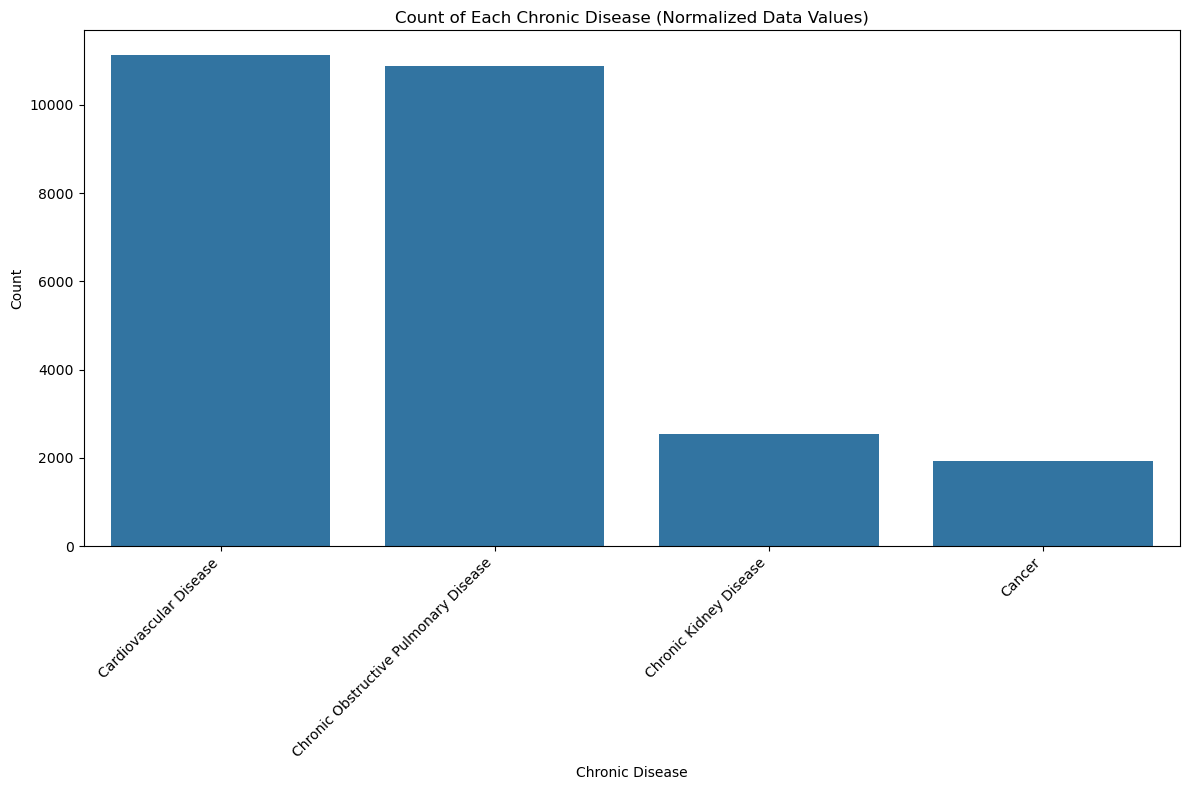

In [16]:
def normalize_data_value(row):
    # Check DataValueUnit first
    if row['DataValueUnit'] == 'per 100,000' or row['DataValueUnit'] == 'cases per 100,000':
        return row['DataValue']
    elif row['DataValueUnit'] == '%':
        return row['DataValue'] * 1000  
    elif row['DataValueUnit'] == 'cases per 1,000,000':
        return row['DataValue'] / 10  
    elif row['DataValueUnit'] == 'Number':
        if row['DataValueType'] in ['Crude Prevalence', 'Age-adjusted Prevalence']:
            return row['DataValue']
        elif row['DataValueType'] in ['Average Annual Age-adjusted Rate', 'Average Annual Crude Rate']:
            return row['DataValue']
        elif row['DataValueType'] == 'Number':
            return row['DataValue']
    else:
        return row['DataValue']

cdi_df_cleaned['NormalizedDataValue'] = cdi_df_cleaned.apply(normalize_data_value, axis=1)



plt.figure(figsize=(12, 8))
sns.countplot(data=cdi_df_cleaned, x='Topic', order=cdi_df_cleaned['Topic'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title("Count of Each Chronic Disease (Normalized Data Values)")
plt.xlabel("Chronic Disease")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


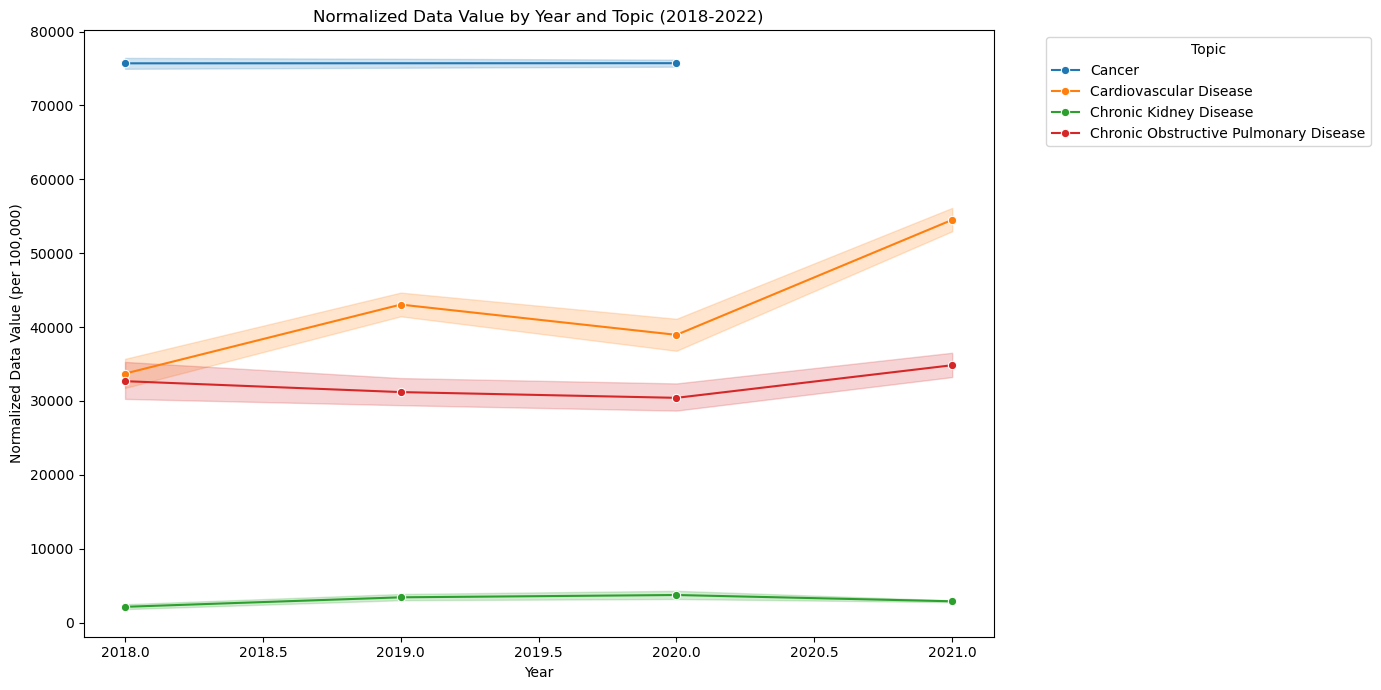

In [18]:
cdi_df_cleaned['YearStart'] = cdi_df_cleaned['YearStart'].astype(int)
df_filtered = cdi_df_cleaned[(cdi_df_cleaned['YearStart'] >= 2018) & (cdi_df_cleaned['YearStart'] <= 2022)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_filtered, x='YearStart', y='NormalizedDataValue', hue='Topic', marker='o')
plt.title('Normalized Data Value by Year and Topic (2018-2022)')
plt.xlabel('Year')
plt.ylabel('Normalized Data Value')
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

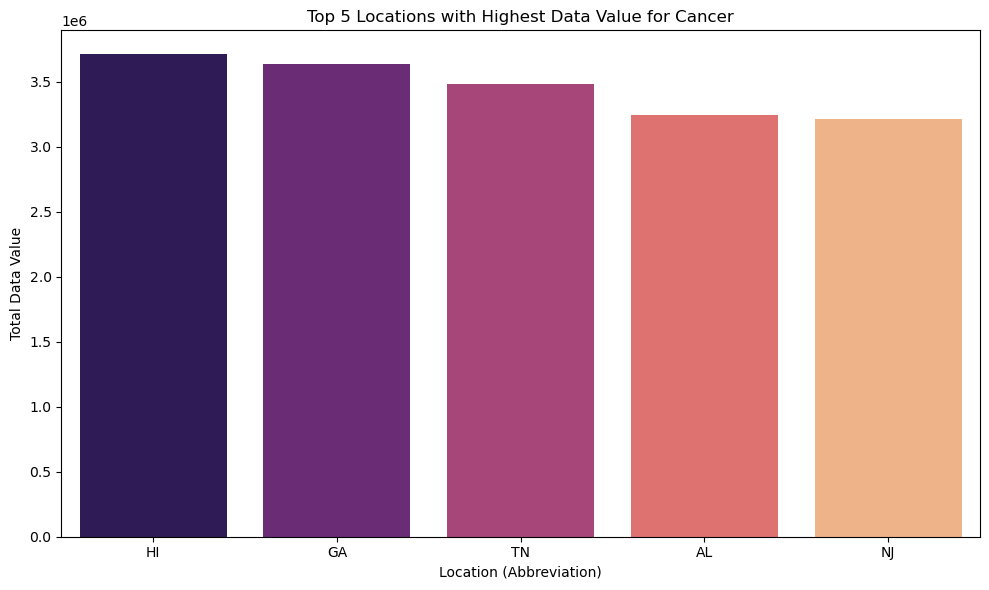

In [20]:
cancer_df = cdi_df_cleaned[cdi_df_cleaned['Topic'] == 'Cancer']

top_5_locations_cancer = (
    cancer_df.groupby('LocationAbbr')['NormalizedDataValue']
    .sum()
    .nlargest(5)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_locations_cancer, x='LocationAbbr', y='NormalizedDataValue', palette='magma', order=top_5_locations_cancer['LocationAbbr'])
plt.title('Top 5 Locations with Highest Data Value for Cancer')
plt.xlabel('Location (Abbreviation)')
plt.ylabel('Total Data Value')
plt.tight_layout()
plt.show()

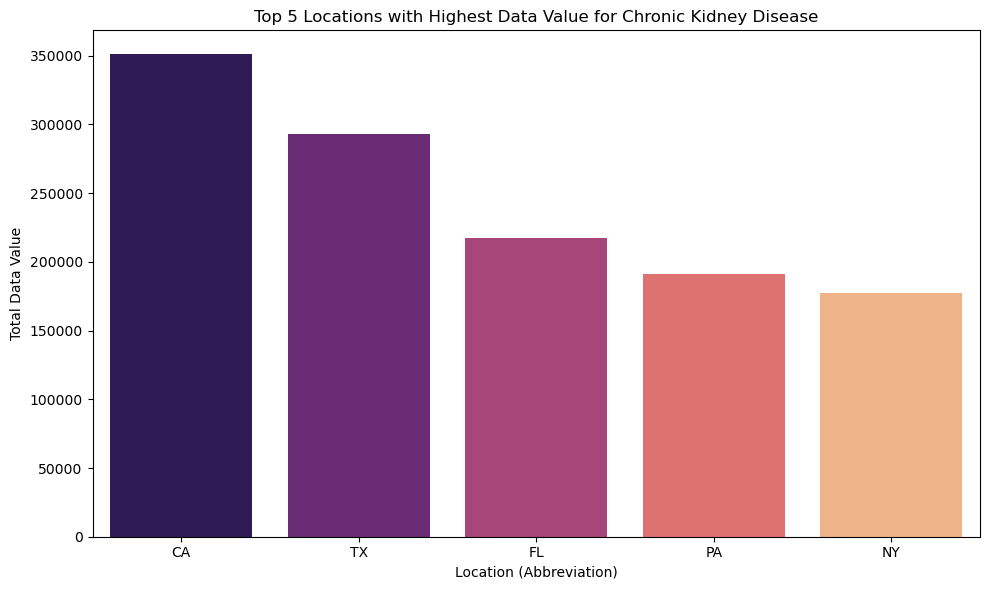

In [22]:
kidney_df = cdi_df_cleaned[cdi_df_cleaned['Topic'] == 'Chronic Kidney Disease']

top_5_locations_kidney = (
    kidney_df.groupby('LocationAbbr')['NormalizedDataValue']
    .sum()
    .nlargest(5)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_locations_kidney, x='LocationAbbr', y='NormalizedDataValue', palette='magma', order=top_5_locations_kidney['LocationAbbr'])
plt.title('Top 5 Locations with Highest Data Value for Chronic Kidney Disease')
plt.xlabel('Location (Abbreviation)')
plt.ylabel('Total Data Value')
plt.tight_layout()
plt.show()

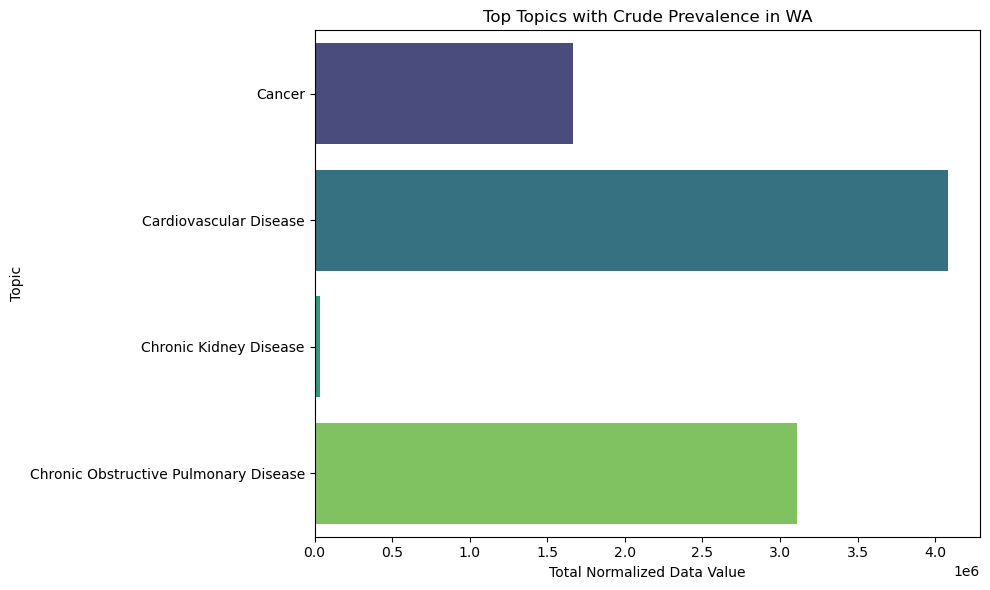

In [24]:
wa_crude_prevalence_df = cdi_df_cleaned[
    (cdi_df_cleaned['LocationAbbr'] == 'WA') & 
    (cdi_df_cleaned['DataValueType'] == 'Crude Prevalence')
]

top_topics_wa_crude = (
    wa_crude_prevalence_df.groupby('Topic')['NormalizedDataValue']
    .sum()
    .nlargest(5)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_topics_wa_crude, x='NormalizedDataValue', y='Topic', palette='viridis')
plt.title('Top Topics with Crude Prevalence in WA')
plt.xlabel('Total Normalized Data Value')
plt.ylabel('Topic')
plt.tight_layout()
plt.show()

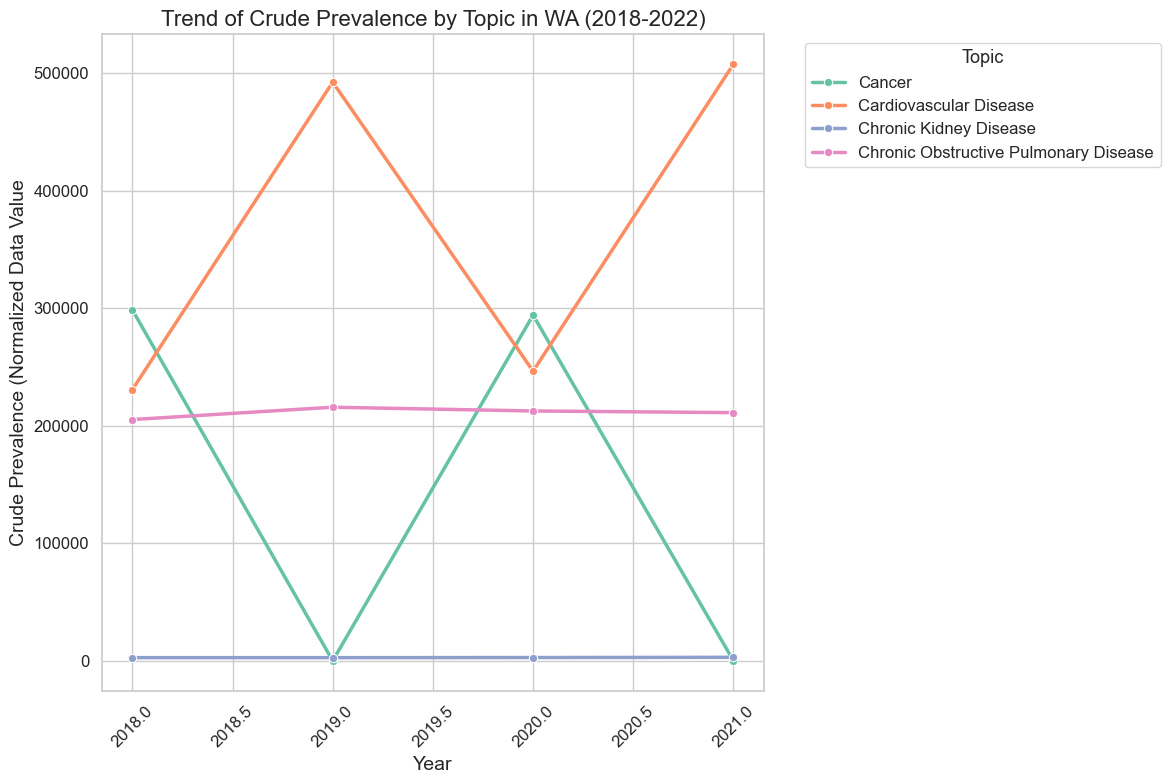

In [26]:
wa_crude_prevalence_df = cdi_df_cleaned[
    (cdi_df_cleaned['LocationAbbr'] == 'WA') &
    (cdi_df_cleaned['DataValueType'] == 'Crude Prevalence') &
    (cdi_df_cleaned['YearStart'].between(2018, 2022))
]

topic_trends = (
    wa_crude_prevalence_df.groupby(['Topic', 'YearStart'])['NormalizedDataValue']
    .sum()
    .reset_index()
)

sns.set(style="whitegrid")

plt.figure(figsize=(12, 8))
sns.lineplot(data=topic_trends, x='YearStart', y='NormalizedDataValue', hue='Topic', marker='o', linewidth=2.5, palette="Set2")
plt.title('Trend of Crude Prevalence by Topic in WA (2018-2022)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Crude Prevalence (Normalized Data Value', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize='13')
plt.tight_layout()

plt.show()

## Activity 1

Start by thinking about what the story is that you want to tell with your dataset. Write a paragraph describing what questions you want to investigate with your data, or what messages you want to convey using the data. Note that, as we progress with the projects, the story you want to tell may change. It's okay if you come back later and revise or update this. But describe what, at the moment, you think your story will be.

## Activity 2

Create a list of which variables in your dataset will be valuable to summarize individually.

For each of these variables in this list, specify one or more possible ways that it could be visualized.  

For each of these variables in this list, either create the visualization(s) you have specified, or identify what is needed before you can do so (this could be a matter of needing some data wrangling to be completed, seeking out supplemental data to merge with your dataset, or needing to learn how to do something in R beyond what we have learned so far). 